In [30]:
import warnings
warnings.filterwarnings('ignore')

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split

In [32]:
data = pd.read_csv('transformed/all_2p_house_races_trainset.csv')
data.head()

,Unnamed: 0,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,...,dem_inc_dummy,rep_inc_dummy,pvi,census_region,dem_scandal_score,rep_scandal_score,Year,Geography,dem_stand,rep_stand
0,0,2014,Alabama,AL,False,AL-01,48278.0,103758.0,152234,Burton LeFlore,...,0,1,-14.460266,East South Central,0.0,0.0,2014.0,AL-01,Burton LeFlore,Bradley Byrne
1,1,2014,Alabama,AL,False,AL-02,54692.0,113103.0,167952,Erick Wright,...,0,1,-16.091761,East South Central,0.0,0.0,2014.0,AL-02,Erick Wright,Martha Roby
2,2,2014,Alabama,AL,False,AL-03,52816.0,103558.0,156620,Jesse Smith,...,0,1,-15.311107,East South Central,0.0,0.0,2014.0,AL-03,Jesse Smith,Mike Rogers
3,3,2014,Alabama,AL,False,AL-06,42291.0,135945.0,178449,Mark Lester,...,0,0,-27.395373,East South Central,0.0,0.0,2014.0,AL-06,Mark Lester,Gary Palmer
4,4,2014,Alaska,AK,False,AK-00,114602.0,142572.0,279741,Forrest Dunbar,...,0,1,-10.647773,Pacific,0.0,1.0,2014.0,AK-00,Forrest Dunbar,Don Young


In [33]:
data.shape

(2331, 54)

In [34]:
data['is_2020'] = data['year'].map(lambda x: 1 if x == 2020 else 0)

In [35]:
data = data.set_index(['year', 'district'])
data.head()

Unnamed: 0    state state_po  special       dem       rep  \
year district                                                              
2014 AL-01              0  Alabama       AL    False   48278.0  103758.0   
     AL-02              1  Alabama       AL    False   54692.0  113103.0   
     AL-03              2  Alabama       AL    False   52816.0  103558.0   
     AL-06              3  Alabama       AL    False   42291.0  135945.0   
     AK-00              4   Alaska       AK    False  114602.0  142572.0   

               totalvotes        dem_cand       rep_cand dem_inc  ...  \
year district                                                     ...   
2014 AL-01         152234  Burton LeFlore  Bradley Byrne   False  ...   
     AL-02         167952    Erick Wright    Martha Roby   False  ...   
     AL-03         156620     Jesse Smith    Mike Rogers   False  ...   
     AL-06         178449     Mark Lester    Gary Palmer   False  ...   
     AK-00         279741  Forrest Dunbar      Don Young   False  ...   

              rep_inc_dummy        pvi       census_region  dem_scandal_score  \
year district                                                                   
2014 AL-01                1 -14.460266  East South Central                0.0   
     AL-02                1 -16.091761  East South Central                0.0   
     AL-03                1 -15.311107  East South Central                0.0   
     AL-06                0 -27.395373  East South Central                0.0   
     AK-00                1 -10.647773             Pacific                0.0   

               rep_scandal_score    Year  Geography       dem_stand  \
year district                                                         
2014 AL-01                   0.0  2014.0      AL-01  Burton LeFlore   
     AL-02                   0.0  2014.0      AL-02    Erick Wright   
     AL-03                   0.0  2014.0      AL-03     Jesse Smith   
     AL-06                   0.0  2014.0      AL-06     Mark Lester   
     AK-00                   1.0  2014.0      AK-00  Forrest Dunbar   

                   rep_stand  is_2020  
year district                          
2014 AL-01     Bradley Byrne        0  
     AL-02       Martha Roby        0  
     AL-03       Mike Rogers        0  
     AL-06       Gary Palmer        0  
     AK-00         Don Young        0  

[5 rows x 53 columns]

In [36]:
data.columns.values

array(['Unnamed: 0', 'state', 'state_po', 'special', 'dem', 'rep',
       'totalvotes', 'dem_cand', 'rep_cand', 'dem_inc', 'rep_inc',
       'dem_funds', 'rep_funds', '2party_votes', 'dem_pct_2p',
       'rep_pct_2p', 'dem_tot_funds', 'rep_tot_funds', 'tot_funds',
       'dem_funds_2p_pct', 'rep_funds_2p_pct', 'dem_poll_avg', 'dem_effn',
       'rep_poll_avg', 'rep_effn', 'seat_number', 'prev_lean',
       'prev2_lean', 'generic_ballot_avg', 'ics', 'cvap_white_pct',
       'cvap_aapi_pct', 'cvap_hisp_pct', 'cvap_black_pct',
       'cvap_natam_pct', 'college', 'demo_cluster', 'district_id',
       'no_dem_cand_flag', 'no_rep_cand_flag', 'dem_inc_any',
       'rep_inc_any', 'dem_inc_dummy', 'rep_inc_dummy', 'pvi',
       'census_region', 'dem_scandal_score', 'rep_scandal_score', 'Year',
       'Geography', 'dem_stand', 'rep_stand', 'is_2020'], dtype=object)

In [37]:
data['rep_tot_funds'].isna().any()

np.False_

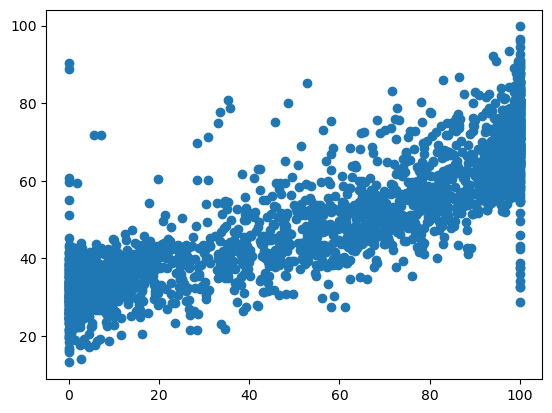

In [38]:
# plt.scatter(np.sqrt(data['dem_effn']) * (data['dem_poll_avg'] - data['rep_poll_avg']), data['dem_pct_2p'])
plt.scatter(data['dem_funds_2p_pct'], data['dem_pct_2p'])

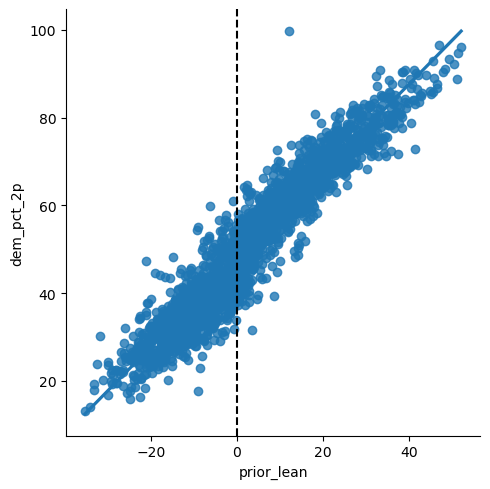

In [39]:
# plt.scatter(data['pvi'] - data['generic_ballot_avg'], data['dem_pct_2p'])
data['prior_lean'] = data['pvi'] - data['generic_ballot_avg']
sns.lmplot(
    data,
    x='prior_lean', y='dem_pct_2p'
)
plt.axvline(0, color='black', linestyle='--')

In [40]:
# sns.scatterplot(
#     data.reset_index(),
#     x='rep_scandal_score', y='dem_pct_2p', hue='year' 
# )

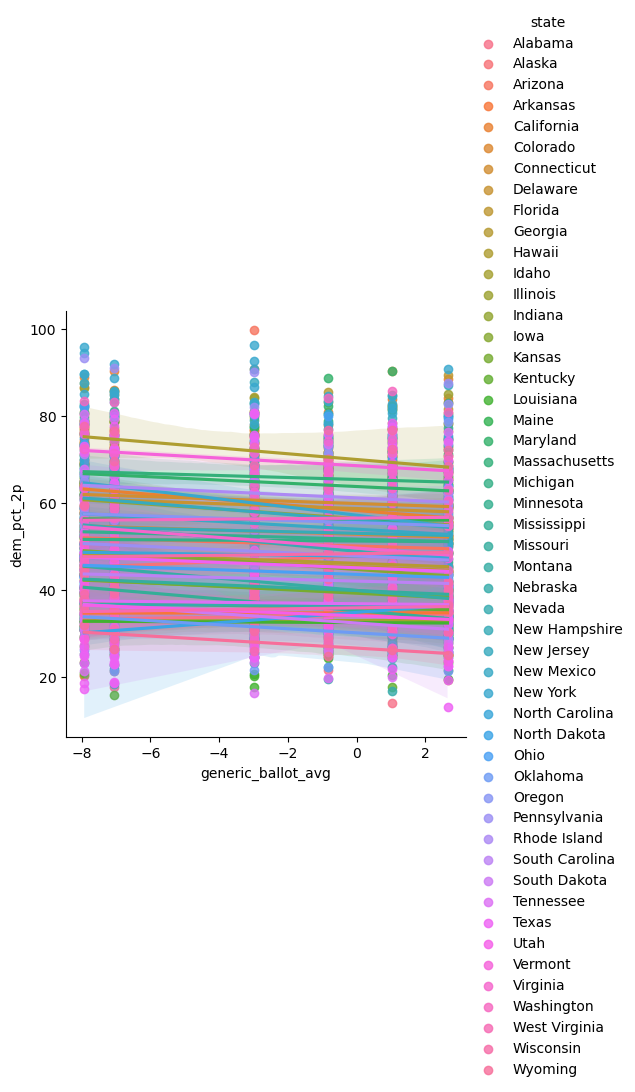

In [41]:
data_resind = data.reset_index()

sns.lmplot(
    data_resind,
    x='generic_ballot_avg', y='dem_pct_2p', hue='state'
)

In [42]:
data['dem_funds_2p_pct_sqrd'] = data['dem_funds_2p_pct']**2
data['sqrt_effn'] = np.sqrt(data['dem_effn'])
data['poll_margin'] = data['dem_poll_avg'] - data['rep_poll_avg']
data['effnXmargin'] = data['sqrt_effn'] * data['poll_margin']

## Preliminary Model Check (Frequentist OLS)

In [67]:
y = data['dem_pct_2p'] - 50
X = data[['pvi', 'generic_ballot_avg',
         'dem_inc_dummy', 'rep_inc_dummy', 'dem_funds_2p_pct_sqrd', 'dem_scandal_score', 'rep_scandal_score']]
         # 'cvap_black_pct', 'cvap_hisp_pct', 'cvap_natam_pct', 'cvap_aapi_pct',
         #'effnXmargin',]] 
          #'college']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [68]:
X.corr()

,pvi,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,dem_scandal_score,rep_scandal_score
pvi,1.000000,0.023357,0.725348,-0.684417,0.797369,0.126623,-0.126428
generic_ballot_avg,0.023357,1.000000,-0.007801,-0.003879,-0.077651,-0.000745,-0.010691
dem_inc_dummy,0.725348,-0.007801,1.000000,-0.748953,0.745404,0.136267,-0.128135
rep_inc_dummy,-0.684417,-0.003879,-0.748953,1.000000,-0.730296,-0.093823,0.163433
dem_funds_2p_pct_sqrd,0.797369,-0.077651,0.745404,-0.730296,1.000000,0.054376,-0.102856
dem_scandal_score,0.126623,-0.000745,0.136267,-0.093823,0.054376,1.000000,-0.018190
rep_scandal_score,-0.126428,-0.010691,-0.128135,0.163433,-0.102856,-0.018190,1.000000


In [69]:
np.linalg.matrix_rank(X)

np.int64(7)

In [70]:
#X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train)
reg = model.fit(cov_type='HC1')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:             dem_pct_2p   R-squared (uncentered):                   0.950
Model:                            OLS   Adj. R-squared (uncentered):              0.950
Method:                 Least Squares   F-statistic:                              5629.
Date:                Thu, 06 Aug 2026   Prob (F-statistic):                        0.00
Time:                        16:38:31   Log-Likelihood:                         -4277.6
No. Observations:                1561   AIC:                                      8569.
Df Residuals:                    1554   BIC:                                      8607.
Df Model:                           7                                                  
Covariance Type:                  HC1                                                  
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
pvi                       0.8353      0.011     74.373      0.000       0.813       0.857
generic_ballot_avg       -0.3258      0.023    -14.318      0.000      -0.370      -0.281
dem_inc_dummy             0.3077      0.283      1.086      0.277      -0.248       0.863
rep_inc_dummy            -4.7724      0.238    -20.038      0.000      -5.239      -4.306
dem_funds_2p_pct_sqrd     0.0004   4.06e-05      9.869      0.000       0.000       0.000
dem_scandal_score        -2.2819      0.901     -2.534      0.011      -4.047      -0.517
rep_scandal_score         2.9772      0.563      5.290      0.000       1.874       4.080
==============================================================================
Omnibus:                      260.116   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3477.622
Skew:                           0.325   Prob(JB):                         0.00
Kurtosis:                      10.283   Cond. No.                     5.39e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are heteroscedasticity robust (HC1)
[3] The condition number is large, 5.39e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [71]:
y_test_hat = reg.predict(X_test)
X_test['residuals'] = y_test_hat - y_test
np.mean((y_test - y_test_hat)**2), np.mean(abs(y_test - y_test_hat))

(np.float64(13.830404218581563), np.float64(2.861869478863027))

In [72]:
y_test - y_test_hat

year  district
2016  NE-02       1.037586
2020  OK-05       1.446357
2022  IL-06      -0.931079
2016  PA-15      -4.423725
2020  PA-17      -0.101177
                    ...   
2014  VA-04      -3.363407
2020  WV-02       4.419343
2014  NE-03      -0.428190
2024  NY-25       0.206245
      OH-11       2.710799
Length: 770, dtype: float64

In [73]:
X_test.corr()

,pvi,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,dem_scandal_score,rep_scandal_score,residuals
pvi,1.000000,0.055324,0.722648,-0.656207,0.786722,0.099650,-0.135127,-0.101404
generic_ballot_avg,0.055324,1.000000,-0.010787,-0.050119,-0.070289,-0.011930,-0.048766,0.070290
dem_inc_dummy,0.722648,-0.010787,1.000000,-0.726128,0.743356,0.113078,-0.122425,-0.110438
rep_inc_dummy,-0.656207,-0.050119,-0.726128,1.000000,-0.707983,-0.082713,0.167369,-0.025914
dem_funds_2p_pct_sqrd,0.786722,-0.070289,0.743356,-0.707983,1.000000,0.023635,-0.090657,-0.163679
dem_scandal_score,0.099650,-0.011930,0.113078,-0.082713,0.023635,1.000000,-0.013844,0.000586
rep_scandal_score,-0.135127,-0.048766,-0.122425,0.167369,-0.090657,-0.013844,1.000000,0.007652
residuals,-0.101404,0.070290,-0.110438,-0.025914,-0.163679,0.000586,0.007652,1.000000


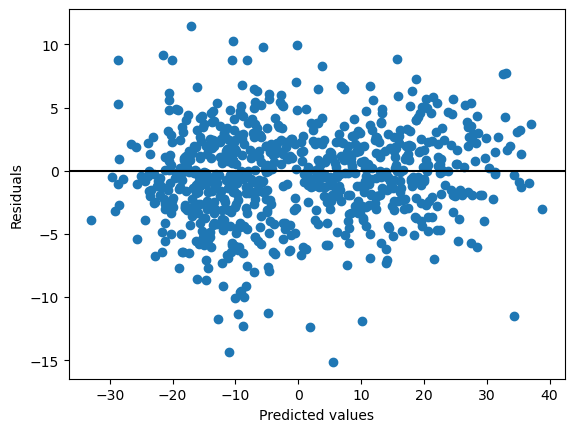

In [74]:
# Residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black')
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

In [75]:
# Residuals
plt.scatter(X_test['prev2_lean'], y_test - y_test_hat)
plt.axhline(0, color='black')
plt.ylabel('Residuals');

KeyError: 'prev2_lean'

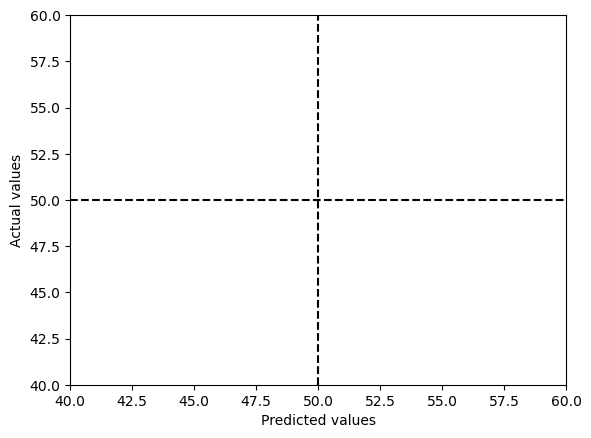

In [77]:
# Actual vs predicted
plt.scatter(y_test_hat, y_test)
plt.axhline(50, color='black', linestyle='--')
plt.axvline(50, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(40, 60)
plt.xlabel('Predicted values')
plt.ylabel('Actual values');

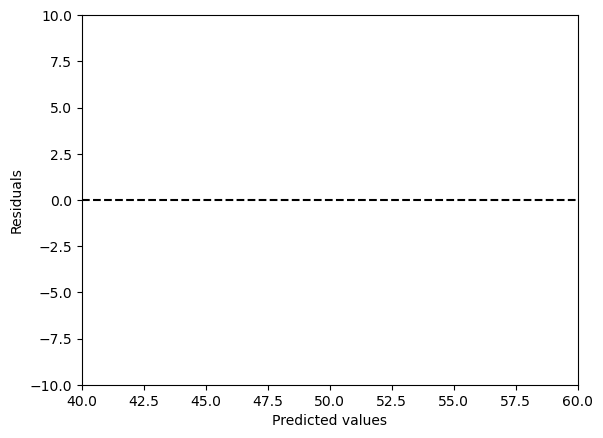

In [78]:
# Actual vs residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(-10, 10)
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

In [59]:
resid = pd.DataFrame(y_test_hat - y_test)
resid = resid.reset_index().rename({0: 'resid'}, axis=1)
resid.head()

,year,district,resid
0,2020,IL-15,1.544257
1,2018,TX-31,-5.173558
2,2018,MD-07,1.652631
3,2018,IN-04,0.361365
4,2022,IN-01,-1.011373


In [76]:
plt.scatter(resid['year'], resid['resid'])
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='black', linestyle='--');

NameError: name 'resid' is not defined

In [61]:
durbin_watson(reg.resid)

np.float64(1.9784027336335988)